In [68]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
sets = pd.read_csv("data/sets.csv")

# LEGO Data Analysis

## Introduction

In this project, we will explore a dataset containing LEGO sets,
themes, colours, and parts.

<img src="images/bricks.jpg" width="500">

### Questions we'll investigate

- What is the largest LEGO set?
- When were the first LEGO sets released?
- Which LEGO theme has the most sets?
- How has the number of LEGO sets changed over time?
- Have LEGO sets become larger over time?

In [5]:
sets

,set_num,name,year,theme_id,num_parts
0,001-1,Town Plan,1955,1,12
1,002-1,Fire Station,1955,1,18
2,003-1,Police Station,1956,1,22
3,004-1,Rescue Helicopter,1957,1,15
4,005-1,Race Car,1958,1,10
5,006-1,Space Explorer,1958,2,25
6,007-1,Castle,1959,3,45
7,008-1,Pirate Ship,1960,4,60
8,1000-1,City Square,1965,1,120
9,1001-1,Fire Rescue,1970,1,150


In [6]:
sets.head()

,set_num,name,year,theme_id,num_parts
0,001-1,Town Plan,1955,1,12
1,002-1,Fire Station,1955,1,18
2,003-1,Police Station,1956,1,22
3,004-1,Rescue Helicopter,1957,1,15
4,005-1,Race Car,1958,1,10


In [7]:
sets.shape

(30, 5)

In [8]:
sets.columns

Index(['set_num', 'name', 'year', 'theme_id', 'num_parts'], dtype='str')

In [14]:
sets["num_parts"].max()

np.int64(4780)

In [18]:
sets.loc[sets["num_parts"].idxmax(),["name","num_parts"]]

name         Millennium Falcon
num_parts                 4780
Name: 28, dtype: object

In [26]:
color = pd.read_csv("data/colors.csv")

In [27]:
color

,id,name,rgb,is_trans
0,1,White,FFFFFF,False
1,2,Black,000000,False
2,3,Red,C91A09,False
3,4,Blue,0055BF,False
4,5,Yellow,F2CD37,False
5,6,Green,237841,False
6,7,Gray,A0A5A9,False
7,8,Brown,583927,False
8,9,Orange,FE8A18,True
9,10,Purple,A5A5CB,True


In [28]:
color["name"].nunique()

10

In [30]:
color["is_trans"].value_counts()

is_trans
False    8
True     2
Name: count, dtype: int64

In [31]:
color.groupby("is_trans").size()

is_trans
False    8
True     2
dtype: int64

In [32]:
### understanding lego themes vs lego sets

In [34]:
sets.head()

,set_num,name,year,theme_id,num_parts
0,001-1,Town Plan,1955,1,12
1,002-1,Fire Station,1955,1,18
2,003-1,Police Station,1956,1,22
3,004-1,Rescue Helicopter,1957,1,15
4,005-1,Race Car,1958,1,10


In [38]:
sets.sort_values("year")[['name','year']].head()

,name,year
0,Town Plan,1955
1,Fire Station,1955
2,Police Station,1956
3,Rescue Helicopter,1957
4,Race Car,1958


In [60]:
sets = pd.read_csv("data/sets.csv")
sets.head()

,set_num,name,year,theme_id,num_parts
0,001-1,Town Plan,1955,1,12
1,002-1,Fire Station,1955,1,18
2,003-1,Police Station,1956,1,22
3,004-1,Rescue Helicopter,1957,1,15
4,005-1,Race Car,1958,1,10


In [61]:
sets[sets["year"] == sets["year"].min()]

,set_num,name,year,theme_id,num_parts
0,001-1,Town Plan,1955,1,12
1,002-1,Fire Station,1955,1,18


In [66]:
sets.sort_values("num_parts",ascending=False).head()

,set_num,name,year,theme_id,num_parts
28,1020-1,Millennium Falcon,2018,18,4780
29,1021-1,Technic Supercar,2020,19,3700
23,1015-1,Ninjago Temple,2008,6,1200
21,1013-1,Friends Mall,2006,12,1100
20,1012-1,City Hospital,2005,11,900


In [75]:
sets_by_year = sets.groupby("year").count()
sets_by_year

,set_num,name,theme_id,num_parts
year,,,,
1955,2,2,2,2
1956,1,1,1,1
1957,1,1,1,1
1958,2,2,2,2
1959,1,1,1,1
1960,1,1,1,1
1965,1,1,1,1
1970,1,1,1,1
1975,1,1,1,1


In [72]:
sets_by_year["set_num"].tail()

year
2012    1
2014    1
2016    1
2018    1
2020    1
Name: set_num, dtype: int64

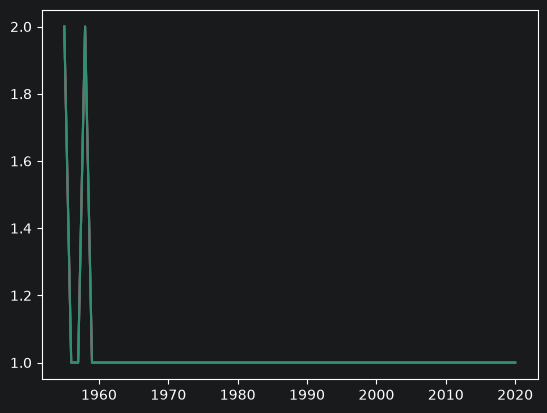

In [78]:
plt.plot(sets_by_year.index,sets_by_year.values)
plt.show()

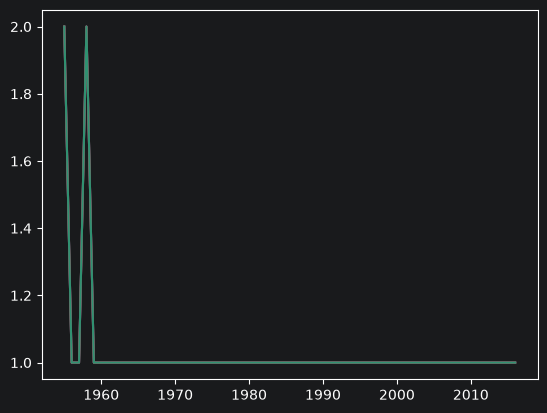

In [79]:
plt.plot(sets_by_year.index[:-2],sets_by_year.values[:-2])

In [80]:
sets

,set_num,name,year,theme_id,num_parts
0,001-1,Town Plan,1955,1,12
1,002-1,Fire Station,1955,1,18
2,003-1,Police Station,1956,1,22
3,004-1,Rescue Helicopter,1957,1,15
4,005-1,Race Car,1958,1,10
5,006-1,Space Explorer,1958,2,25
6,007-1,Castle,1959,3,45
7,008-1,Pirate Ship,1960,4,60
8,1000-1,City Square,1965,1,120
9,1001-1,Fire Rescue,1970,1,150


In [87]:
themes_by_year = sets.groupby("year").agg({
    "theme_id":pd.Series.nunique
})

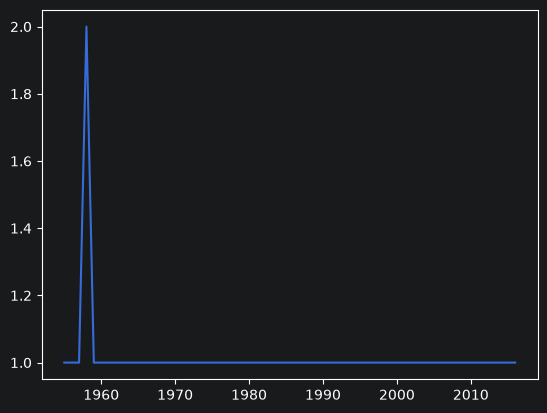

In [90]:
plt.plot(themes_by_year.index[:-2],themes_by_year.values[:-2])

Text(0, 0.5, 'Number of themes')

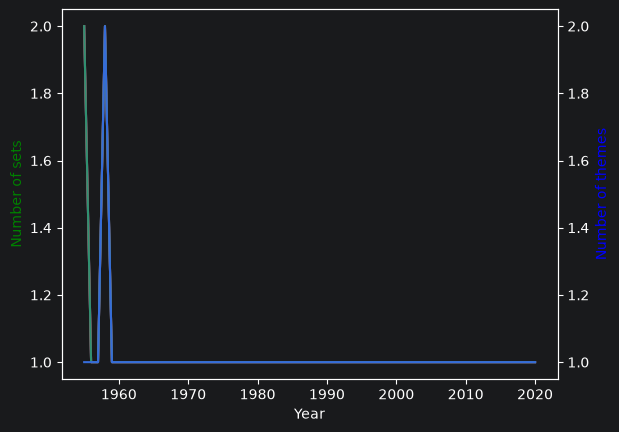

In [92]:
ax1 = plt.gca() # get current axes
ax2 = ax1.twinx()

ax1.plot(sets_by_year.index,sets_by_year.values)
ax2.plot(themes_by_year.index,themes_by_year.values)

ax1.set_xlabel("Year")
ax1.set_ylabel("Number of sets",color="green")
ax2.set_ylabel("Number of themes",color="blue")

In [95]:
parts_per_set = sets.groupby("year").agg({
    "num_parts":pd.Series.mean
})

In [96]:
parts_per_set

,num_parts
year,
1955,15.0
1956,22.0
1957,15.0
1958,17.5
1959,45.0
1960,60.0
1965,120.0
1970,150.0
1975,180.0


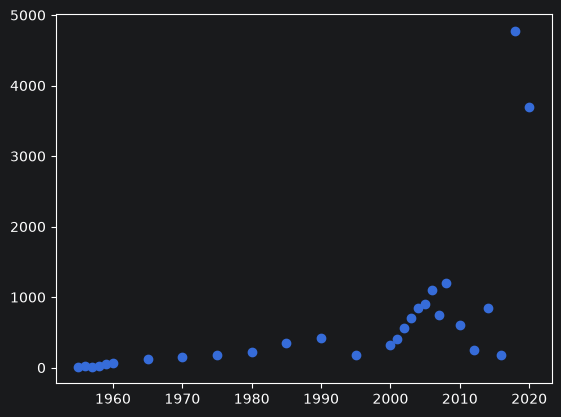

In [97]:
plt.scatter(parts_per_set.index,parts_per_set.values)

In [124]:
set_theme_count = sets["theme_id"].value_counts().reset_index()
set_theme_count.columns = ["id", "set_count"]

In [125]:
set_theme_count[:5]

,id,set_count
0,1,8
1,2,2
2,3,2
3,4,2
4,6,2


In [121]:
themes = pd.read_csv("data/themes.csv")

In [123]:
themes.head()

,id,name,parent_id
0,1,Town,NaN
1,2,Space,NaN
2,3,Castle,NaN
3,4,Pirates,NaN
4,5,Friends,NaN


In [110]:
themes[themes['name'] == "Star Wars"]

,id,name,parent_id
8,9,Star Wars,NaN


In [118]:
# merging using keys



In [128]:
merged_df = pd.merge(set_theme_count, themes, on="id")
merged_df.head()

,id,set_count,name,parent_id
0,1,8,Town,NaN
1,2,2,Space,NaN
2,3,2,Castle,NaN
3,4,2,Pirates,NaN
4,6,2,Ninjago,NaN


In [130]:
merged_df = merged_df.sort_values("set_count", ascending=False)
merged_df.head()

,id,set_count,name,parent_id
0,1,8,Town,NaN
1,2,2,Space,NaN
2,3,2,Castle,NaN
3,4,2,Pirates,NaN
4,6,2,Ninjago,NaN


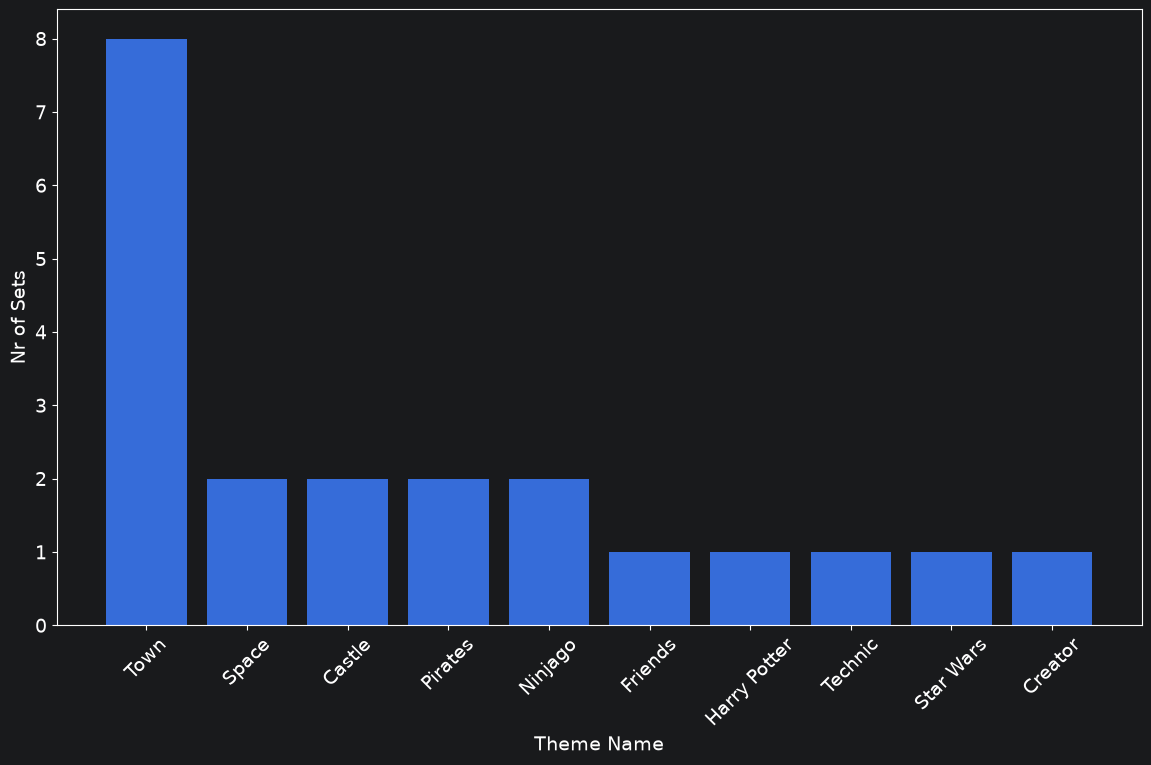

In [131]:
plt.figure(figsize=(14, 8))

plt.xticks(fontsize=14, rotation=45)
plt.yticks(fontsize=14)

plt.ylabel("Nr of Sets", fontsize=14)
plt.xlabel("Theme Name", fontsize=14)

plt.bar(
    merged_df["name"].head(10),
    merged_df["set_count"].head(10)
)

plt.show()